In [1]:
import torch
import torch.nn as nn 
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [4]:
torch.eye(3)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

In [5]:
def random_SSM(N, rng=None):
    A = torch.rand(N, N)
    B = torch.rand(N, 1)
    C = torch.rand(1, N)

    return A, B, C

# Discretization using Tustin's method
def discretize(A, B, C, step):
    I = torch.eye(A.shape[0])
    BL = torch.inverse(I - (step / 2.0) * A)
    Ab = BL @ (I + (step / 2.0) * A)
    Bb = (BL * step) @ B
    return Ab, Bb, C

In [3]:
A, B, C = random_SSM(15) # N = 3
Ab, Bb, Cb = discretize(A, B, C, step=0.01)


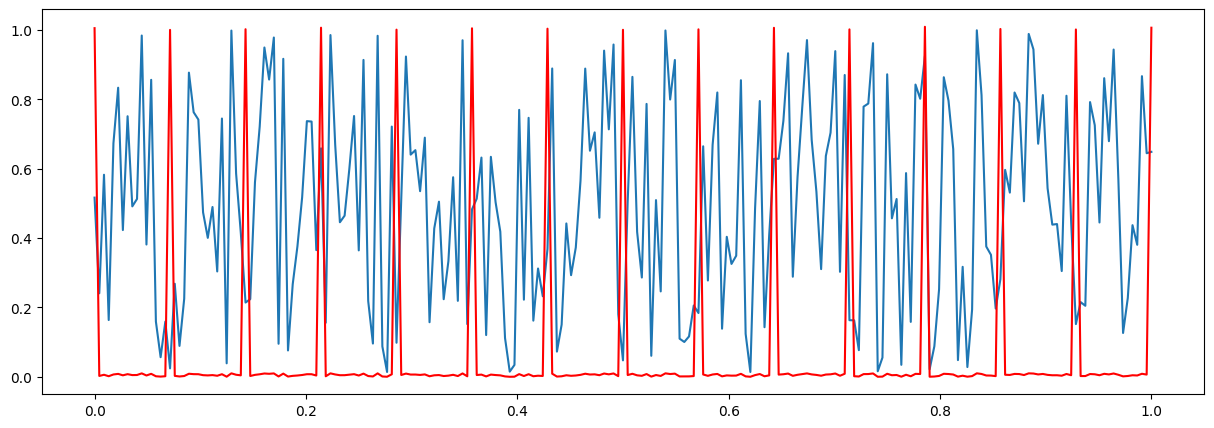

In [4]:
test_A = A.view(-1).numpy()
test_Ab = Ab.view(-1).numpy()
t = np.linspace(0, 1, len(test_A))
# size of plot 
plt.figure(figsize=(15, 5))
plt.plot(t, test_A)
plt.plot(t, test_Ab, 'r')
plt.show()

In [6]:
import torch

def scan_SSM(Ab, Bb, Cb, u, x0):
    """
    State Space Model scan
    
    Args:
        Ab: State transition matrix
        Bb: Input matrix
        Cb: Output matrix
        u: Input sequence (seq_len, input_dim) or (seq_len, batch, input_dim) (L, B, D)
        x0: Initial state
        
    Returns:
        final_x: The hidden state at the last time step
        stacked_y: The sequence of outputs (seq_len, ...)
    """
    
    # Initialize state
    x_k = x0
    ys = []
    
    # Iterate over the time dimension (0th axis of u)
    for u_k in u:
        # State update: x_k = A @ x_{k-1} + B @ u_k
        x_k = Ab @ x_k + Bb @ u_k
        
        # Output calculation: y_k = C @ x_k
        y_k = Cb @ x_k
        
        # Collect output
        ys.append(y_k)
    
    # Stack the list of outputs into a single tensor
    stacked_y = torch.stack(ys)
    
    # Return final state and the sequence of outputs
    return x_k, stacked_y

In [ ]:
def run_SSM(A, B, C, u):
    L = u.shape[0] # Input shape, sequence length
    N = A.shape[0] # State space dimension
    Ab, Bb, Cb = discretize(A, B, C, step=1.0 / L)  # Uniform steps 1/length

    # Run recurrence
    return scan_SSM(Ab, Bb, Cb, u[:, torch.newaxis], torch.zeros((N,)))[1] # stacked_y

To gain some more intuition and test our SSM implementation, we pause from machine learning to implement a classic example from mechanics.

In this example, we consider the forward position 

y(t) of a mass attached to a wall with a spring. Over time, varying force u(t) is applied to this mass. The system is parameterized by mass (m), spring constant (k), friction constant (b). We can relate these with the following differential equation:

$$ 
my''(t)=u(t)−by'(t)−ky(t)
$$ 
 

In [8]:
def example_mass(k, b, m):
    A = torch.tensor([[0, 1], [-k / m, -b / m]])
    B = torch.tensor([[0], [1.0 / m]])
    C = torch.tensor([[1.0, 0]])
    return A, B, C

In [9]:
def example_force(t):
    x = torch.sin(10 * t)
    
    # Create a boolean mask where x > 0.5 and multiply
    # True becomes 1.0, False becomes 0.0
    return x * (x > 0.5)


Animation saved!


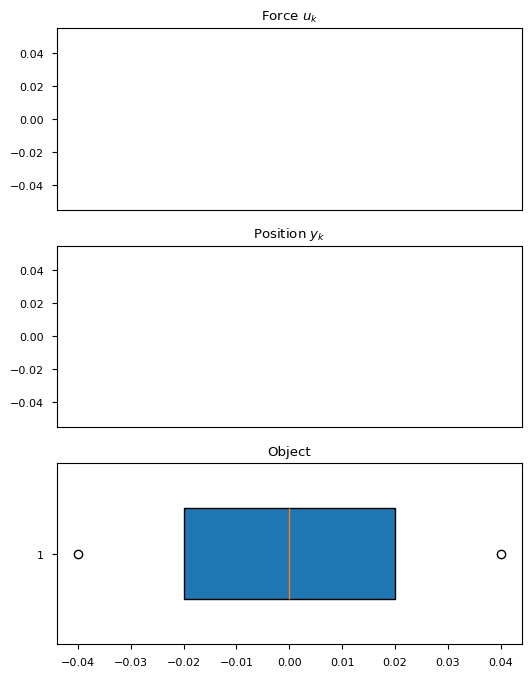

In [22]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation  # Standard library
import torch

def example_ssm():
    # --- 1. Simulation Setup ---
    ssm = example_mass(k=40, b=5, m=1) 
    L = 100
    step = 1.0 / L
    ks = torch.arange(L)
    u = example_force(ks * step)
    y = run_SSM(*ssm, u)
    

    # --- 2. Setup Figure ---
    plt.style.use('seaborn-v0_8-paper')
    fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(6, 8))

    # --- 3. Define the Animation Update Function ---
    def update(k):
        # We must clear the axes because boxplots are hard to 'update' otherwise
        ax1.clear()
        ax2.clear()
        ax3.clear()
        
        # Redraw Titles and Ticks (since .clear() removes them)
        ax1.set_title("Force $u_k$"); ax1.set_xticks([])
        ax2.set_title("Position $y_k$"); ax2.set_xticks([])
        ax3.set_title("Object")

        # Plot the data up to current frame k
        # We add max(k, 1) to avoid indexing errors at start
        current_slice = slice(0, max(k, 1))
        
        ax1.plot(ks[current_slice], u[current_slice], color="red")
        ax2.plot(ks[current_slice], y[current_slice], color="blue")
        
        # Draw Boxplot
        current_y = y[k, 0].item() if k < len(y) else y[-1, 0].item()
        ax3.boxplot(
            [current_y - 0.04, current_y, current_y + 0.04],
            showcaps=False, whis=False, vert=False, widths=0.5,
            patch_artist=True
        )

    # --- 4. Create and Save Animation ---
    anim = animation.FuncAnimation(fig, update, frames=range(0, L, 2), interval=100)
    
    anim.save("line.gif", dpi=150, writer="imagemagick")
    print("Animation saved!")

# Run it
example_ssm()

## Training SSMs: The Convolutional Representation

In [9]:
def K_conv(Ab, Bb, Cb, L):
    return torch.stack(
        [(Cb @ torch.linalg.matrix_power(Ab, l) @ Bb).reshape() for l in range(L)]
    )

In [10]:
import torch
import torch.nn.functional as F

def causal_convolution(u, K, nofft=False):
    """
    Assumes u and K are 1D tensors of shape (N,).

    u: input signal
    K: kernel
    """
    # Ensure inputs are tensors
    if not isinstance(u, torch.Tensor):
        u = torch.tensor(u)
    if not isinstance(K, torch.Tensor):
        K = torch.tensor(K)
        
    n = u.shape[-1]
    
    if nofft:
        # --- Direct Convolution Branch ---
        
        # 1. Reshape inputs for F.conv1d
        #    Input: (Batch=1, Channel=1, Length=N)
        u_unsqueezed = u.view(1, 1, -1)
        
        # 2. Prepare Kernel
        #    PyTorch conv1d calculates cross-correlation. To match math convolution
        #    (and scipy.signal.convolve), we must flip the kernel.
        #    Shape: (Out=1, In=1, Length=N)
        K_flipped = K.flip(-1).view(1, 1, -1)
        
        # 3. "Full" Convolution
        #    To emulate mode='full', padding must be kernel_size - 1.
        out = F.conv1d(u_unsqueezed, K_flipped, padding=n - 1)
        
        # 4. Squeeze back to 1D and truncate to causal length
        return out.view(-1)[:n]

    else:
        # --- FFT Branch ---
        assert K.shape[-1] == u.shape[-1], "K and u must be same size for this implementation"

        # 1. Pad signals with zeros to prevent circular convolution artifacts
        #    F.pad syntax is (padding_left, padding_right)
        u_pad = F.pad(u, (0, n))
        K_pad = F.pad(K, (0, n))

        # 2. Real-input Fast Fourier Transform
        ud = torch.fft.rfft(u_pad)
        Kd = torch.fft.rfft(K_pad)

        # 3. Element-wise multiplication in frequency domain
        out_fft = ud * Kd

        # 4. Inverse FFT
        #    We specify n=2*n to ensure the output length matches the padded length
        out = torch.fft.irfft(out_fft, n=2 * n)
        
        # 5. Truncate to original length
        return out[:n] # 


In [11]:
import torch
import torch.nn as nn
import math

def log_step_initializer(tensor, dt_min=0.001, dt_max=0.1):
    """
    In-place initializer for log step sizes.
    Initializes the tensor uniformly between log(dt_min) and log(dt_max).
    """
    # 1. Calculate the bounds in the log domain
    min_val = math.log(dt_min)
    max_val = math.log(dt_max)
    
    # 2. Apply Uniform initialization in-place
    #    This is mathematically equivalent to:
    #    random_uniform * (log_max - log_min) + log_min
    nn.init.uniform_(tensor, a=min_val, b=max_val)

    return tensor

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class MultiChannelSSMLayer(nn.Module):
    def __init__(self, H, N, l_max, decode=False):
        """
        Args:
            H: Number of features (channels). This replaces the vmap.
            N: State dimension.
            l_max: Maximum sequence length.
        """
        super().__init__()
        self.H = H
        self.N = N
        self.l_max = l_max
        self.decode = decode

        # --- 1. Vectorized Parameters ---
        # Instead of (N, N), we initialize (H, N, N) to have H independent copies.
        
        # Transition Matrix A: (H, N, N)
        self.A = nn.Parameter(torch.randn(H, N, N) / N**0.5)
        
        # Input/Output Projections: (H, N, 1) and (H, 1, N)
        self.B = nn.Parameter(torch.randn(H, N, 1) / N**0.5)
        self.C = nn.Parameter(torch.randn(H, 1, N) / N**0.5)
        
        # Skip Connection: (H, 1) to broadcast per channel
        self.D = nn.Parameter(torch.ones(H, 1))

        # Step size: (H, 1) - each channel learns its own timescale
        self.log_step = nn.Parameter(
            torch.rand(H, 1) * (np.log(0.1) - np.log(0.001)) + np.log(0.001)
        )

        # RNN Cache: (H, N) - State for each channel
        self.register_buffer("x_k_1", torch.zeros(H, N))

    def _discretize_and_compute_kernel(self):
        """
        Compute H different kernels in parallel using batched operations.
        """
        # dt: (H, 1) -> (H, 1, 1) for broadcasting
        dt = torch.exp(self.log_step).unsqueeze(-1)
        
        # Identity: (H, N, N)
        I = torch.eye(self.N, device=self.A.device).unsqueeze(0).expand(self.H, -1, -1)
        
        # --- Batched Discretization ---
        # PyTorch solve handles batches: (H, N, N) inputs work automatically
        # (I - dt/2 * A)^-1
        left_term = torch.linalg.solve(I - (dt / 2) * self.A, I) 
        
        A_bar = left_term @ (I + (dt / 2) * self.A)  # Shape: (H, N, N)
        B_bar = left_term @ (dt * self.B)            # Shape: (H, N, 1)
        
        # --- Batched Kernel Construction --- State Space Model scan --> scan_SSM
        # We calculate K for all H channels simultaneously
        K_list = []
        curr_B = B_bar
        for _ in range(self.l_max):
            # C @ curr_B -> (H, 1, N) @ (H, N, 1) -> (H, 1, 1)
            k_t = (self.C @ curr_B).view(self.H) 
            K_list.append(k_t)
            
            # Update state: A_bar @ curr_B -> (H, N, N) @ (H, N, 1)
            curr_B = A_bar @ curr_B
            
        # Stack to get (H, L)
        K = torch.stack(K_list, dim=1)  # The sequence of outputs (seq_len, ...)
        return K, A_bar, B_bar

    def forward(self, u):
        """
        u: Input of shape (Batch, H, Length)
        """
        K, A_bar, B_bar = self._discretize_and_compute_kernel()
        
        if not self.decode:
            # --- CNN Mode (Training) ---
            
            # 1. Prepare Kernel for Depthwise Convolution
            #    We want to convolve input channel i with kernel i.
            #    Conv1d Weight Shape: (Out_Channels, In_Channels/Groups, Length)
            #    Target Shape: (H, 1, L)
            K_conv = K.flip(1).unsqueeze(1) 
            
            # 2. Depthwise Convolution
            #    Setting groups=H ensures each input channel sees only its own kernel
            #    Padding ensures causality
            out_conv = F.conv1d(
                u, 
                K_conv, 
                padding=self.l_max - 1, 
                groups=self.H
            )
            
            # Slice to remove extra padding
            out_conv = out_conv[:, :, :self.l_max]
            
            # Add Skip Connection (D broadcasted over length)
            return out_conv + (self.D * u)

        else:
            # --- RNN Mode (Inference) ---
            # Process one timestep. u is (Batch, H)
            
            # Ensure cache is expanded for batch size: (Batch, H, N)
            batch_size = u.shape[0]
            if self.x_k_1.dim() == 2:
                 # (H, N) -> (1, H, N) -> (B, H, N)
                current_x = self.x_k_1.unsqueeze(0).expand(batch_size, -1, -1)
            else:
                current_x = self.x_k_1

            # u: (Batch, H) -> (Batch, H, 1)
            u_in = u.unsqueeze(-1)

            # 1. Update State
            #    A_bar: (H, N, N)
            #    current_x: (Batch, H, N) -> needs (Batch, H, N, 1) for matmul
            #    B_bar: (H, N, 1)
            
            # Perform Batched Matrix Multiplication
            # (Batch, H, N, N) @ (Batch, H, N, 1) -> (Batch, H, N, 1)
            
            # Expand A_bar and B_bar for Batch dimension
            A_bar_batched = A_bar.unsqueeze(0) # (1, H, N, N)
            B_bar_batched = B_bar.unsqueeze(0) # (1, H, N, 1)
            
            next_x = (A_bar_batched @ current_x.unsqueeze(-1)) + (B_bar_batched @ u_in.unsqueeze(-1))
            
            # 2. Compute Output
            #    C: (H, 1, N) -> (1, H, 1, N)
            C_batched = self.C.unsqueeze(0)
            y = C_batched @ next_x # -> (Batch, H, 1, 1)
            
            # Save Cache (remove singleton dims)
            self.x_k_1 = next_x.squeeze(-1)
            
            return y.view(batch_size, self.H) + (self.D.T * u)

In [16]:
A = nn.Parameter(torch.randn(3, 2, 2) / 2**0.5)

log_step = nn.Parameter(log_step_initializer(torch.rand(3, 1), dt_min=0.001, dt_max=0.1))
log_step

Parameter containing:
tensor([[-6.0462],
        [-4.6511],
        [-5.6073]], requires_grad=True)

In [21]:
# Create a layer with 128 hidden features (H) and state dimension 64 (N)
layer = MultiChannelSSMLayer(H=128, N=64, l_max=100)

# Input: Batch=16, Features=128, Length=100
u = torch.randn(16, 128, 100)

# Forward pass (CNN mode)
y = layer(u) # Output: (16, 128, 100)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SequenceBlock(nn.Module):
    def __init__(self, layer_cls, layer_args, d_model, dropout, prenorm=True, glu=True, decode=False):
        """
        Args:
            layer_cls: The class of the inner layer (e.g., SSMLayer).
            layer_args: Dictionary of arguments to initialize layer_cls.
            d_model: Hidden dimension size.
            dropout: Dropout probability.
            prenorm: Whether to apply LayerNorm before the layer (True) or after (False).
            glu: Whether to use Gated Linear Unit for the output projection.
            decode: Mode flag (Training vs Inference).
        """
        super().__init__()
        self.d_model = d_model
        self.prenorm = prenorm
        self.glu = glu
        self.decode = decode
        
        # 1. Instantiate the Inner Layer (SSM)
        #    We pass the 'decode' flag to the inner layer if it supports it
        self.seq = layer_cls(**layer_args, decode=decode)
        
        # 2. Normalization
        self.norm = nn.LayerNorm(d_model)
        
        # 3. Output Projections
        self.out = nn.Linear(d_model, d_model)
        if self.glu:
            self.out2 = nn.Linear(d_model, d_model)
            
        # 4. Dropout
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: Input tensor (Batch, Length, d_model)
        """
        skip = x
        
        # --- Pre-Norm ---
        if self.prenorm:
            x = self.norm(x)
            
        # --- Inner Layer (SSM) ---
        x = self.seq(x)
        
        # --- Activation & Dropout ---
        x = self.drop(F.gelu(x))
        
        # --- GLU (Gated Linear Unit) ---
        if self.glu:
            # Gating mechanism: Signal * Sigmoid(Gate)
            # This allows the model to select which features flow through
            gate = torch.sigmoid(self.out2(x))
            x = self.out(x) * gate
        else:
            x = self.out(x)
            
        # --- Residual Connection ---
        # Note: We apply dropout to the residual path as well, matching the Flax code
        x = skip + self.drop(x)
        
        # --- Post-Norm ---
        if not self.prenorm:
            x = self.norm(x)
            
        return x



In [24]:
# --- Example Usage ---
# Assuming you have the SSMLayer defined from previous steps:
layer_args = {'H': 128, 'N': 64, 'l_max': 100}
block = SequenceBlock(
    layer_cls=MultiChannelSSMLayer, 
    layer_args=layer_args, 
    d_model=128, 
    dropout=0.1
)

In [25]:
block

SequenceBlock(
  (seq): MultiChannelSSMLayer()
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (out): Linear(in_features=128, out_features=128, bias=True)
  (out2): Linear(in_features=128, out_features=128, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
)

In [26]:
import torch
import torch.nn as nn

class Embedding(nn.Module):
    def __init__(self, num_embeddings, features):
        """
        Args:
            num_embeddings: Vocabulary size.
            features: Dimension of the embedding vectors.
        """
        super().__init__()
        # In the Flax code, np.where(x > 0, y, 0.0) zeroes out embeddings where input is 0.
        # PyTorch does this efficiently with 'padding_idx=0'.
        self.embedding = nn.Embedding(num_embeddings, features, padding_idx=0)

    def forward(self, x):
        # The Flax code used x[..., 0], implying the input had an extra dimension 
        # (e.g., shape [Batch, Length, 1] instead of [Batch, Length]).
        # We replicate this safe-guard:
        if x.dim() > 1 and x.shape[-1] == 1:
            x = x.squeeze(-1)
            
        return self.embedding(x)

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# Assuming Embedding and SequenceBlock are defined as in previous steps

class StackedModel(nn.Module):
    def __init__(
        self, 
        layer_cls, 
        layer_args, 
        d_output, 
        d_model, 
        n_layers, 
        prenorm=True, 
        dropout=0.0, 
        embedding=False, 
        classification=False, 
        decode=False
    ):
        super().__init__()
        self.embedding = embedding
        self.classification = classification
        self.decode = decode
        self.d_output = d_output
        self.d_model = d_model

        # 1. Encoder
        if self.embedding:
            # Uses the Embedding class we defined previously (or nn.Embedding)
            self.encoder = Embedding(d_output, d_model)
        else:
            # For continuous data (e.g., pixels), input dim is usually 1
            self.encoder = nn.Linear(1, d_model)

        # 2. The Stack of Layers
        #    Use ModuleList to register layers properly in PyTorch
        self.layers = nn.ModuleList([
            SequenceBlock(
                layer_cls=layer_cls,
                layer_args=layer_args,
                d_model=d_model,
                dropout=dropout,
                prenorm=prenorm,
                decode=decode
            )
            for _ in range(n_layers)
        ])

        # 3. Decoder
        self.decoder = nn.Linear(d_model, d_output)

    def forward(self, x):
        """
        x shape: (Batch, Length) for embedding=True
        x shape: (Batch, Length, 1) or (Batch, Length) for embedding=False
        """
        
        # --- Preprocessing ---
        if not self.classification:
            # 1. Normalize pixels
            if not self.embedding:
                x = x / 255.0
                
            # 2. Time-Shift (Autoregressive Teacher Forcing)
            #    If we are training to generate, we shift input by 1.
            #    Input: [A, B, C] -> Output Target: [B, C, D]
            #    Shifted Input to Model: [0, A, B]
            if not self.decode:
                if self.embedding:
                     # For embeddings, x is (Batch, Length)
                    x_pad = F.pad(x[:, :-1], (1, 0), value=0) 
                    x = x_pad
                else:
                    # For continuous, x is (Batch, Length, 1) or (Batch, Length)
                    # We assume (Batch, Length, 1) for the linear encoder
                    if x.dim() == 2:
                        x = x.unsqueeze(-1)
                    
                    # Pad the sequence dimension (dim 1)
                    # F.pad format for 3D input (B, L, C) is (pad_last_dim, pad_last_dim, pad_seq_dim...)
                    # We want to pad sequence dimension. 
                    x_shifted = x[:, :-1, :]
                    x = torch.cat([torch.zeros_like(x[:, 0:1, :]), x_shifted], dim=1)

        # --- Encoder ---
        # Ensure correct shape for Linear encoder if input is (Batch, Length)
        if not self.embedding and x.dim() == 2:
             x = x.unsqueeze(-1)
             
        x = self.encoder(x)

        # --- Layer Stack ---
        for layer in self.layers:
            x = layer(x)

        # --- Post-processing ---
        if self.classification:
            # Global Average Pooling over sequence length (Dim 1)
            x = torch.mean(x, dim=1)

        # --- Decoder ---
        x = self.decoder(x)

        # --- Output ---
        return F.log_softmax(x, dim=-1)

In [1]:
import torch

def make_HiPPO(N: int) -> torch.Tensor:
    """
    Creates the HiPPO-LegS matrix in PyTorch.
    Formula:
      A_nk = - (2n+1)^(1/2) * (2k+1)^(1/2)   if n > k
      A_nk = - (n+1)                         if n = k
      A_nk = 0                               if n < k
    """
    # 1. Create the scaling terms sqrt(2n+1)
    # shape: (N,)
    n_vals = torch.arange(N, dtype=torch.float32)
    p_vals = torch.sqrt(1 + 2 * n_vals)

    # 2. Compute the outer product: p_n * p_k
    # shape: (N, N)
    # unsqueeze(-1) makes it (N, 1), unsqueeze(0) makes it (1, N)
    A = p_vals.unsqueeze(1) * p_vals.unsqueeze(0)

    # 3. Apply lower triangular mask
    A = torch.tril(A)

    # 4. Fix the diagonal
    # Current diag is (2n+1). We want (n+1).
    # So we subtract n.
    diagonal_adjustment = torch.diag(n_vals)
    A = A - diagonal_adjustment

    # 5. Return negative A (standard convention for stability)
    return -A

In [2]:
make_HiPPO(3)

tensor([[-1.0000, -0.0000, -0.0000],
        [-1.7321, -2.0000, -0.0000],
        [-2.2361, -3.8730, -3.0000]])